In [3]:
import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns
import scipy.stats as stats
import operator
from scipy.stats import fligner, bartlett, levene, sem, t

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
from cafo_iowa.utils.utils import save_geojson_with_lists

from functools import reduce
from shapely import wkt

import cafo_iowa.db.session as s
from cafo_iowa.estimate.estimate import load_and_process_facilities
import statsmodels.formula.api as smf
from cafo_iowa.utils.visualize import plot_facility_example

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset


pd.set_option("display.max_columns", None)

sns.set_theme(style="white", palette="Set1")

au_plot_limit = 2500
uncertainty = True

In [4]:
import cafo_iowa.db.session as s
from cafo_iowa.estimate.estimate import load_and_process_facilities
import statsmodels.formula.api as smf
from cafo_iowa.utils.visualize import plot_facility_example

In [7]:
facilities = load_and_process_facilities()

# Select all facilities that have swine
facilities_swine = facilities[
    (facilities.reported_swine_animal_units > 0)
    & (facilities.swine_cat_combined.isin(["swine_wean", "swine_grow"]))
].copy()

2026-01-31 01:37:04,627 - INFO - Number of facilities loaded: 9785



Facility Summary:
Total facilities: 9785
Empty facilities: 154
Facilities with barns: 9631


In [8]:
print("Facilities: ", len(facilities))
print("Barns in facilities: ", facilities["barn_ids"].explode().nunique())
print("Facilities with swine (wean and grow): ", len(facilities_swine))
print(
    "Barns in facilities with swine: ",
    facilities_swine["barn_ids"].explode().nunique(),
)
print("Facilities with no barns: ", np.sum(facilities.barn_count == 0))
print("Swine facilities with no barns: ", np.sum(facilities_swine.barn_count == 0))
print("Mean barns per facility: ", round(facilities["barn_count"].mean(), 2))
print(
    f"N permits in swine facilities: {facilities_swine.permit_ids.explode().nunique()}"
)
print(
    f"N parcels in swine facilities: {facilities_swine.parcel_ids.explode().nunique()}"
)
print(f"N barns in swine facilities: {facilities_swine.barn_ids.explode().nunique()}")
print(
    f"Mean barns per swine facility: {round(facilities_swine['barn_count'].mean(), 2)}"
)
print(
    f"Mean SQM per swine facility: {round(facilities_swine['barn_area_sqm'].mean(), 2)}"
)
print(
    f"Mean reported animal units per swine facility: {round(facilities_swine['reported_animal_units'].mean(), 2)}"
)
print(
    f"Mean estimated animal units per swine facility: {round(facilities_swine['estimated_animal_units'].mean(), 2)}"
)
print(f"N permits in dataset: {facilities_swine.permit_ids.explode().nunique()}")

Facilities:  9785
Barns in facilities:  26243
Facilities with swine (wean and grow):  6556
Barns in facilities with swine:  13935
Facilities with no barns:  154
Swine facilities with no barns:  31
Mean barns per facility:  2.68
N permits in swine facilities: 6766
N parcels in swine facilities: 8249
N barns in swine facilities: 13935
Mean barns per swine facility: 2.13
Mean SQM per swine facility: 2817.2
Mean reported animal units per swine facility: 1299.75
Mean estimated animal units per swine facility: 1276.55
N permits in dataset: 6766


In [9]:
# Swine facilities with between 400 and 500 reported animal units and 200 or less (but not 0) estimated animal units:  25
print(
    "Swine facilities with between 400 and 500 reported animal units and 200 or less (but not 0) estimated animal units: ",
    len(
        facilities_swine[
            (facilities_swine["reported_animal_units"].between(400, 500))
            & (facilities_swine["estimated_animal_units"] <= 200)
            & (facilities_swine["estimated_animal_units"] > 0)
            & (facilities_swine["animal_cat_combined"] == "swine")
        ]
    ),
)
# Swine facilities with between 400 and 500 reported animal units and 1000 or more estimated animal units:  78
print(
    "Swine facilities with between 400 and 500 reported animal units and 1000 or more estimated animal units: ",
    len(
        facilities_swine[
            (facilities_swine["reported_animal_units"].between(400, 500))
            & (facilities_swine["estimated_animal_units"] >= 1000)
            & (facilities_swine["animal_cat_combined"] == "swine")
        ]
    ),
)

# Swine facilities with between 960 and 1000 reported animal units and 500 or less (but not 0) estimated animal units:  77
print(
    "Swine facilities with between 960 and 1000 reported animal units and 500 or less (but not 0) estimated animal units: ",
    len(
        facilities_swine[
            (facilities_swine["reported_animal_units"].between(960, 1000))
            & (facilities_swine["estimated_animal_units"] <= 500)
            & (facilities_swine["estimated_animal_units"] > 0)
            & (facilities_swine["animal_cat_combined"] == "swine")
        ]
    ),
)

# Swine facilities with between 960 and 1000 reported animal units and 1500 or more estimated animal units:  127
print(
    "Swine facilities with between 960 and 1000 reported animal units and 1500 or more estimated animal units: ",
    len(
        facilities_swine[
            (facilities_swine["reported_animal_units"].between(960, 1000))
            & (facilities_swine["estimated_animal_units"] >= 1500)
            & (facilities_swine["animal_cat_combined"] == "swine")
        ]
    ),
)

Swine facilities with between 400 and 500 reported animal units and 200 or less (but not 0) estimated animal units:  0
Swine facilities with between 400 and 500 reported animal units and 1000 or more estimated animal units:  27
Swine facilities with between 960 and 1000 reported animal units and 500 or less (but not 0) estimated animal units:  4
Swine facilities with between 960 and 1000 reported animal units and 1500 or more estimated animal units:  64


In [10]:
# Drop facilities with other animals
nrows_before = facilities_swine.shape[0]
facilities_swine = facilities_swine[
    facilities_swine.swine_cat_combined != "swine_and_other_animal"
].copy()

print(
    f"Dropped {(nrows_before - facilities_swine.shape[0]) * 100 / nrows_before:.1f}% ({nrows_before - facilities_swine.shape[0]})  facilities that house swine and other animals"
)

# Drop all swine types other than wean and grow
# nrows_before = facilities_swine.shape[0]
# facilities_swine = facilities_swine[
#     facilities_swine.swine_cat_combined.isin(["swine_wean", "swine_grow"])
# ].copy()
# print(
#     f"Dropped {(nrows_before - facilities_swine.shape[0]) * 100 / nrows_before:.1f}% ({nrows_before - facilities_swine.shape[0]}) facilities that house not grow or wean swine"
# )

# remove facilities with 0 reported animal units
nrows_before = facilities_swine.shape[0]
facilities_swine = facilities_swine[facilities_swine.reported_animal_units > 0]
print(
    f"Dropped {(nrows_before - facilities_swine.shape[0]) * 100 / nrows_before:.1f}% ({nrows_before - facilities_swine.shape[0]}) facilities with 0 reported animal units"
)

# remove facilities with 0 estimated animal units
nrows_before = facilities_swine.shape[0]
facilities_swine = facilities_swine[facilities_swine.estimated_animal_units > 0]
print(
    f"Dropped {(nrows_before - facilities_swine.shape[0]) * 100 / nrows_before:.1f}% ({nrows_before - facilities_swine.shape[0]}) facilities with 0 estimated animal units"
)

Dropped 0.0% (0)  facilities that house swine and other animals
Dropped 0.0% (0) facilities with 0 reported animal units
Dropped 0.5% (31) facilities with 0 estimated animal units


In [11]:
# Find duplicated permit IDs
duplicated_permits = facilities_swine[
    facilities_swine.permit_ids.duplicated(keep=False)
]
if len(duplicated_permits) > 0:
    print(f"There are {len(duplicated_permits)} duplicated permit IDs")
    print(duplicated_permits)

In [12]:
permits = gpd.read_postgis(
    "SELECT * from processed.permits WHERE swine_animal_units > 0",
    s.get_engine(),
    geom_col="geometry",
)

In [13]:
# change reported animal units exactly at threshold to x - 1, to account for rounding (e.g. 999.6 becomes 1000)
thresholds = {
    500: "Medium CAFO threshold (MMP required)",
    1000: "Large CAFO threshold (Construction permit & MMP required)",
    # 2000: "Between-facility separation distance increases",
}
adjusted_values = [t - 1 for t in thresholds]
columns_to_update = ["reported_animal_units", "reported_swine_animal_units"]

for col in columns_to_update:
    for threshold, adjusted in zip(thresholds, adjusted_values):
        facilities_swine.loc[facilities_swine[col] == threshold, col] = adjusted

columns_to_update = ["animal_units"]

for col in columns_to_update:
    for threshold, adjusted in zip(thresholds, adjusted_values):
        permits.loc[permits[col] == threshold, col] = adjusted

In [14]:
# value counts of top reported animal units, as share of total
top_values = facilities_swine.reported_animal_units.value_counts(normalize=True).head(
    10
)
print(top_values)

reported_animal_units
960     0.160307
996     0.082299
480     0.057471
999     0.054253
1920    0.051954
2000    0.042759
1600    0.042605
992     0.038314
998     0.038314
800     0.029732
Name: proportion, dtype: float64


In [15]:
print(permits.animal_units.value_counts(normalize=True).head(10))

# Calculate share of permits with animal units between 960 and 999
mask_960_999 = (permits.animal_units >= 960) & (permits.animal_units <= 999)
share_960_999 = mask_960_999.mean()
print(f"\nShare of permits with animal units between 960-999: {share_960_999:.1%}")

# Get total count
count_960_999 = mask_960_999.sum()
total_permits = len(permits)
print(
    f"Count of permits with animal units between 960-999: {count_960_999:,} out of {total_permits:,} total permits"
)

animal_units
960     0.137331
996     0.066606
480     0.062028
999     0.048295
1920    0.044518
1600    0.035935
2000    0.035477
992     0.034905
998     0.032044
800     0.027810
Name: proportion, dtype: float64

Share of permits with animal units between 960-999: 33.5%
Count of permits with animal units between 960-999: 2,927 out of 8,738 total permits


In [16]:
# add variables
facilities_swine["swine_cat_combined_label"] = (
    facilities_swine.swine_cat_combined.replace(
        {
            "swine_wean": "Wean-to-Finish",
            "swine_grow": "Grow-to-Finish",
            "swine_nurs": "Nursery",
            "swine_gilt": "Gilt",
            "swine_sow": "Sow",
            "swine_gest": "Gestation",
            "two_or_more_swine_types": "Multiple types",
        }
    )
)
facilities_swine["animal_difference"] = (
    facilities_swine["reported_animal_units"]
    - facilities_swine["estimated_animal_units"]
)

facilities_swine["animal_difference_pct"] = (
    facilities_swine["animal_difference"] / facilities_swine["reported_animal_units"]
)

# Define bin edges:
bins = [0, 299] + list(range(300, 2500, 100)) + [np.inf]

# Define bin labels:
bin_labels = ["0-299"] + [f"{i}-{i+99}" for i in range(300, 2500, 100)] + ["2500+"]

# Bin the reported animal units using pd.cut.
facilities_swine["reported_animal_units_bin"] = pd.cut(
    facilities_swine["reported_animal_units"],
    bins=bins,
    labels=bin_labels,
    include_lowest=True,
    ordered=True,
)

# Figure: Satellite images of facilities

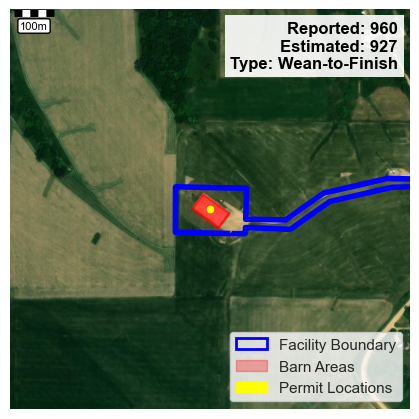

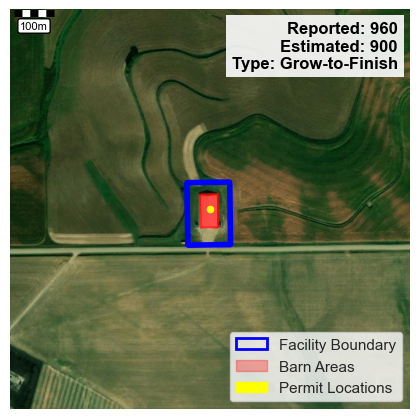

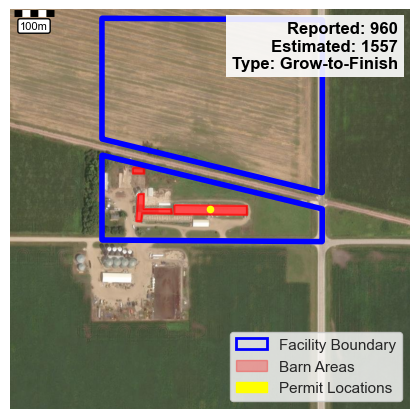

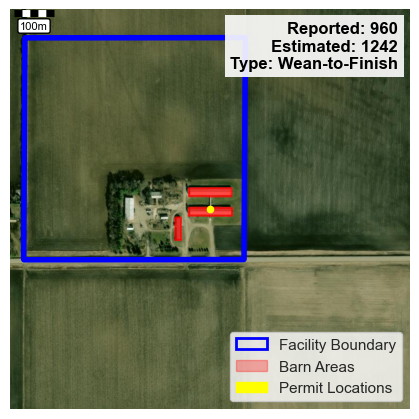

In [17]:
# Figure 1: Satellite imagery of facilities and labels
facility_ids = [
    "007311f37ac40e8363ca4184fddfe408",
    "018bb2175be398abd4adde555b96b714",
    "0a800a751bd0a57bb20248a28552a069",
    "27ef0c7460654ce7802d660616e73480",
]


# Combine selections (should be 4 facilities total)
selected_facilities = facilities_swine[facilities_swine.facility_id.isin(facility_ids)]

# plot each facility
for i, row in selected_facilities.iterrows():
    facility_id = row["facility_id"]
    # print(facility_id)
    plot_facility_example(
        row,
        show_facility=True,
        show_barns=True,
        show_permits=True,
        show_text=True,
        show_legend=True,
        show_scale=True,
        buffer=500,
        figsize=(4, 4),
        save_path=f"output/plots/satellite_facility_{facility_id}.png",
    )

# Figure 2: Histogram of reported animal units

/var/folders/xj/nk_7447d20gcrbftkc9p3hk40000gn/T/ipykernel_67865/1024129232.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


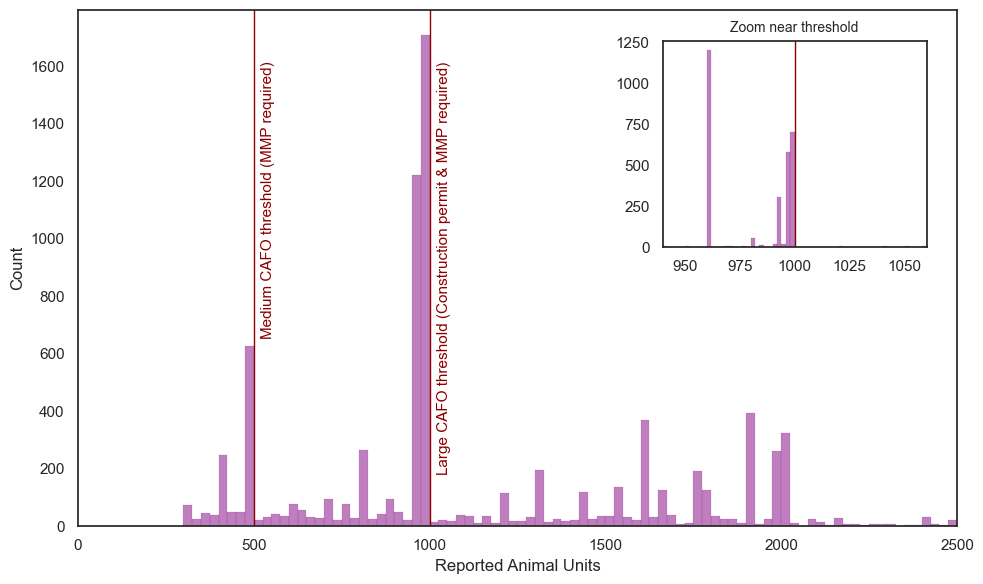

In [18]:
# Define your threshold and zoom range
focus_threshold = 1000
zoom_width = 60
zoom_range = (focus_threshold - zoom_width, focus_threshold + zoom_width)

# Main histogram
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    data=permits,
    x="animal_units",
    binwidth=25,
    ax=ax,
    zorder=1,
    edgecolor="purple",
    color="purple",
    alpha=0.5,
)

# Add threshold lines and labels
for threshold, label in thresholds.items():
    ax.axvline(
        threshold,
        color="darkred",
        # linestyle="--",
        lw=1,
        zorder=2,
        label=f"{label} ({threshold} AUs)",
    )
    ax.text(
        threshold + 20,
        ax.get_ylim()[1] * 0.9,
        label,
        color="darkred",
        fontsize=11,
        verticalalignment="top",
        rotation=90,
    )

# Main plot labels
ax.set_xlabel("Reported Animal Units")
ax.set_ylabel("Count")
ax.set_xlim(0, au_plot_limit)

# === Inset Axes ===
axins = inset_axes(ax, width="30%", height="40%", loc="upper right", borderpad=2)
sns.histplot(
    data=permits[
        (permits["animal_units"] >= zoom_range[0])
        & (permits["animal_units"] <= zoom_range[1])
    ],
    x="animal_units",
    binwidth=2,
    ax=axins,
    edgecolor="purple",
    color="purple",
    alpha=0.5,
    lw=0.1,
)

# Inset plot styling
axins.set_xlabel("")
axins.set_ylabel("")
axins.axvline(focus_threshold, color="darkred", lw=1)
axins.set_xlim(*zoom_range)
axins.set_title("Zoom near threshold", fontsize=10)
# axins.set_yticklabels([])


# === Connect inset to main plot ===
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="none")

plt.tight_layout()
plt.savefig("output/plots/hist_reported_swine_aus.png", dpi=300)
plt.show()

# Figure: Reported vs. Estimated, histogram

In [19]:
# select facility types to include
included_types = ["Wean-to-Finish", "Grow-to-Finish"]
facilities_swine = facilities_swine[
    facilities_swine.swine_cat_combined_label.isin(included_types)
]

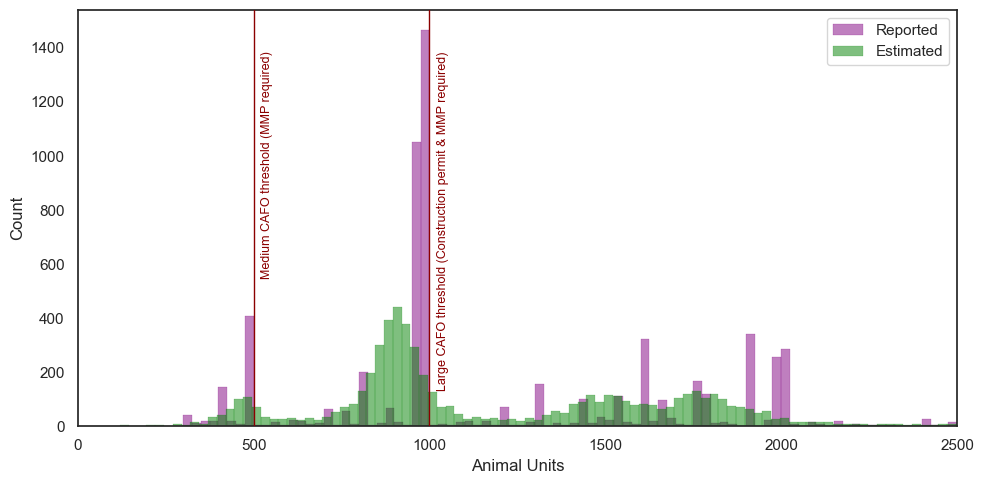

In [20]:
# Create single plot
fig, ax = plt.subplots(figsize=(10, 5))

# Plot reported AUs histogram
sns.histplot(
    data=facilities_swine[
        facilities_swine.swine_cat_combined_label.isin(included_types)
    ],
    x="reported_animal_units",
    binwidth=25,
    ax=ax,
    edgecolor="purple",
    color="purple",
    alpha=0.5,
    label="Reported",
    zorder=1,
)

# Plot estimated AUs histogram
sns.histplot(
    data=facilities_swine[
        facilities_swine.swine_cat_combined_label.isin(included_types)
    ],
    x="estimated_animal_units",
    binwidth=25,
    ax=ax,
    zorder=2,
    edgecolor="green",
    color="green",
    alpha=0.5,
    label="Estimated",
)

# Add vertical lines with labels for thresholds
for threshold, label in thresholds.items():
    ax.axvline(
        threshold,
        color="darkred",
        # linestyle="--",
        lw=1,
        zorder=3,
    )
    ax.text(
        threshold + 20,
        ax.get_ylim()[1] * 0.9,
        label,
        color="darkred",
        fontsize=9,
        verticalalignment="top",
        rotation=90,
    )

ax.set_xlabel("Animal Units")
ax.set_ylabel("Count")
ax.set_xlim(0, au_plot_limit)
ax.legend()

plt.tight_layout()

# Save and show
plt.savefig("output/plots/hist_reported_vs_estimated_aus.png", dpi=300)
plt.show()

# Numbers for paper

In [21]:
def summarize_near_threshold(df, lower, upper, threshold):
    subset = df[df.reported_animal_units.between(lower, upper)]
    n_total = len(subset)
    n_above = (subset.estimated_animal_units >= threshold).sum()
    n_25_higher = (subset.estimated_animal_units >= threshold * 1.25).sum()
    n_50_higher = (subset.estimated_animal_units >= threshold * 1.5).sum()

    print(f"\nNumber of facilities near threshold ({lower}-{upper}): {n_total}")
    print(f"  Estimated ≥ {threshold}: {n_above} ({n_above / n_total:.1%} of total)")
    if n_above > 0:
        print(
            f"    Estimated ≥ {threshold * 1.25:.0f} (25% higher): {n_25_higher} "
            f"({n_25_higher / n_total:.1%} of total, {n_25_higher / n_above:.1%} of above-threshold)"
        )
        print(
            f"    Estimated ≥ {threshold * 1.5:.0f} (50% higher): {n_50_higher} "
            f"({n_50_higher / n_total:.1%} of total, {n_50_higher / n_above:.1%} of above-threshold)"
        )

    return subset, n_total, n_above, n_25_higher, n_50_higher


def estimate_threshold_uncertainty(fac_df, threshold, n_total, n_above):
    above, above_25, above_50 = [], [], []

    n_samples = len(fac_df.estimated_animal_units_samples.iloc[0])

    for i in range(n_samples):
        sample_i = fac_df.estimated_animal_units_samples.apply(lambda x: x[i])
        above_i = sample_i >= threshold
        above.append(above_i.sum())
        above_25.append((sample_i >= threshold * 1.25).sum())
        above_50.append((sample_i >= threshold * 1.5).sum())

    def get_bounds(arr, denom):
        lo, hi = np.percentile(arr, [2.5, 97.5])
        return lo, hi, lo / denom * 100, hi / denom * 100

    return {
        "n_total": n_total,
        "n_above": n_above,
        "above": get_bounds(above, n_total),
        "above_25": {
            "total": get_bounds(above_25, n_total),
            "conditional": get_bounds(above_25, n_above) if n_above > 0 else None,
        },
        "above_50": {
            "total": get_bounds(above_50, n_total),
            "conditional": get_bounds(above_50, n_above) if n_above > 0 else None,
        },
    }


def combine_bounds(arr_a, arr_b, denom_total, denom_above):
    lo = arr_a[0] + arr_b[0]
    hi = arr_a[1] + arr_b[1]
    pct_lo_total = lo / denom_total * 100
    pct_hi_total = hi / denom_total * 100
    pct_lo_cond = lo / denom_above * 100
    pct_hi_cond = hi / denom_above * 100
    return {
        "total": (lo, hi, pct_lo_total, pct_hi_total),
        "conditional": (lo, hi, pct_lo_cond, pct_hi_cond),
    }


def combine_cis(ci_a, ci_b):
    total = ci_a["n_total"] + ci_b["n_total"]
    above = ci_a["n_above"] + ci_b["n_above"]
    return {
        "n_total": total,
        "n_above": above,
        "above": combine_bounds(ci_a["above"], ci_b["above"], total, above)["total"],
        "above_25": combine_bounds(
            ci_a["above_25"]["total"], ci_b["above_25"]["total"], total, above
        ),
        "above_50": combine_bounds(
            ci_a["above_50"]["total"], ci_b["above_50"]["total"], total, above
        ),
    }


def print_ci(label, bounds):
    lo, hi, pct_lo_total, pct_hi_total = bounds["total"]
    print(
        f"  {label}: {lo:.0f} – {hi:.0f} facilities ({pct_lo_total:.1f}% – {pct_hi_total:.1f}% of total)"
    )
    if bounds["conditional"]:
        lo, hi, pct_lo_cond, pct_hi_cond = bounds["conditional"]
        print(f"     ({pct_lo_cond:.1f}% – {pct_hi_cond:.1f}% of above-threshold)")


# --- Summarize near-threshold facilities ---
fac_near_500, n_500, n_500_above, n_500_25, n_500_50 = summarize_near_threshold(
    facilities_swine, 460, 499, 500
)
fac_near_1000, n_1000, n_1000_above, n_1000_25, n_1000_50 = summarize_near_threshold(
    facilities_swine, 960, 999, 1000
)

# --- Combined totals ---
n_total = n_500 + n_1000
n_total_above = n_500_above + n_1000_above
n_total_25 = n_500_25 + n_1000_25
n_total_50 = n_500_50 + n_1000_50

print(f"\nTotal near-threshold facilities: {n_total}")
print(
    f"  Estimated ≥ threshold: {n_total_above} ({n_total_above / n_total:.1%} of total)"
)
print(
    f"    ≥ 20% over: {n_total_25} ({n_total_25 / n_total:.1%} of total, {n_total_25 / n_total_above:.1%} of above-threshold)"
)
print(
    f"    ≥ 50% over: {n_total_50} ({n_total_50 / n_total:.1%} of total, {n_total_50 / n_total_above:.1%} of above-threshold)"
)

# --- Uncertainty estimation ---
ci_500 = estimate_threshold_uncertainty(fac_near_500, 500, n_500, n_500_above)
ci_1000 = estimate_threshold_uncertainty(fac_near_1000, 1000, n_1000, n_1000_above)

# --- Combine CIs ---
ci_total = combine_cis(ci_500, ci_1000)

# --- Print uncertainty intervals ---
print("\nUncertainty intervals (95%) for facilities above threshold:")
print("Threshold: 500 AU")
print_ci("  ≥ 500", {"total": ci_500["above"], "conditional": None})
print_ci("  ≥ 600 (25% over)", ci_500["above_25"])
print_ci("  ≥ 750 (50% over)", ci_500["above_50"])

print("\nThreshold: 1000 AU")
print_ci("  ≥ 1000", {"total": ci_1000["above"], "conditional": None})
print_ci("  ≥ 1200 (25% over)", ci_1000["above_25"])
print_ci("  ≥ 1500 (50% over)", ci_1000["above_50"])

print("\nCombined (460–499 and 960–999):")
print_ci("  ≥ threshold", {"total": ci_total["above"], "conditional": None})
print_ci("  ≥ 25% over", ci_total["above_25"])
print_ci("  ≥ 50% over", ci_total["above_50"])


Number of facilities near threshold (460-499): 415
  Estimated ≥ 500: 190 (45.8% of total)
    Estimated ≥ 625 (25% higher): 99 (23.9% of total, 52.1% of above-threshold)
    Estimated ≥ 750 (50% higher): 69 (16.6% of total, 36.3% of above-threshold)

Number of facilities near threshold (960-999): 2519
  Estimated ≥ 1000: 415 (16.5% of total)
    Estimated ≥ 1250 (25% higher): 130 (5.2% of total, 31.3% of above-threshold)
    Estimated ≥ 1500 (50% higher): 64 (2.5% of total, 15.4% of above-threshold)

Total near-threshold facilities: 2934
  Estimated ≥ threshold: 605 (20.6% of total)
    ≥ 20% over: 229 (7.8% of total, 37.9% of above-threshold)
    ≥ 50% over: 133 (4.5% of total, 22.0% of above-threshold)

Uncertainty intervals (95%) for facilities above threshold:
Threshold: 500 AU
    ≥ 500: 121 – 336 facilities (29.2% – 81.0% of total)
    ≥ 600 (25% over): 81 – 116 facilities (19.5% – 28.0% of total)
     (42.6% – 61.1% of above-threshold)
    ≥ 750 (50% over): 53 – 81 facilities 

In [22]:
# calculate total reported and estimated animal units in bunching region (460-499 or 960-999)
bunchin_region = facilities_swine[
    facilities_swine.reported_animal_units.between(460, 499)
    | facilities_swine.reported_animal_units.between(960, 999)
]
total_reported_aus = bunchin_region.reported_animal_units.sum()
total_estimated_aus = bunchin_region.estimated_animal_units.sum()
print(f"Total reported animal units in bunching region: {total_reported_aus:.2f}")
print(f"Total estimated animal units in bunching region: {total_estimated_aus:.2f}")
print(
    f"Ratio of total estimated to reported animal units in bunching region: {total_estimated_aus/total_reported_aus:.2f}"
)

Total reported animal units in bunching region: 2670234.00
Total estimated animal units in bunching region: 2662522.02
Ratio of total estimated to reported animal units in bunching region: 1.00


# Figure: Reported vs Estimated, scatter


/Users/hclo/Documents/cafo_iowa/venv/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)


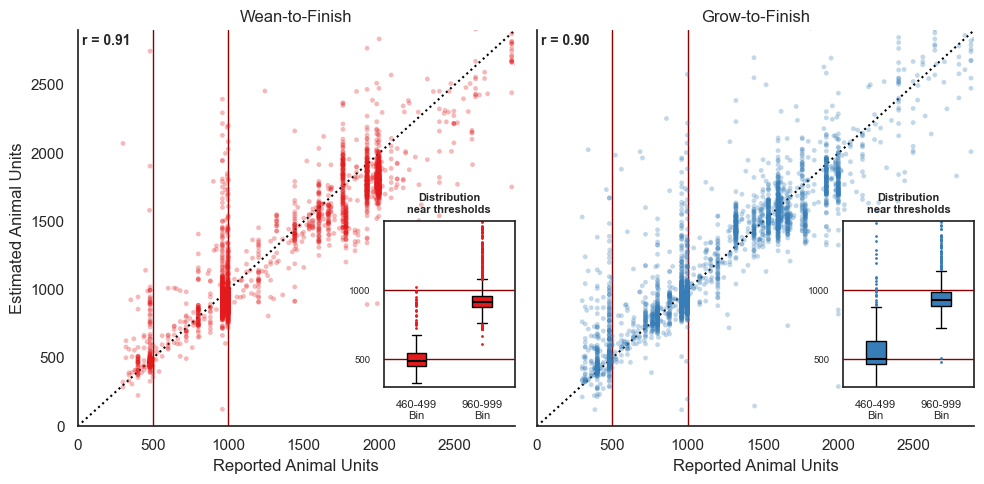

In [23]:
au_plot_limit = 2900
uncertainty = False

# Base faceted scatter plot
g = sns.lmplot(
    data=facilities_swine[
        facilities_swine.swine_cat_combined_label.isin(included_types)
    ],
    x="reported_animal_units",
    y="estimated_animal_units",
    col="swine_cat_combined_label",
    hue="swine_cat_combined_label",
    col_wrap=2,
    height=5,
    scatter_kws={"alpha": 0.3, "s": 12, "edgecolor": "none", "zorder": 2},
    fit_reg=False,
)

# higlihgt zoomed in region in main plot


# Extract hue -> color mapping from the plot
hue_order = included_types
palette = sns.color_palette(n_colors=len(hue_order))
hue_color_map = dict(zip(hue_order, palette))


# Add vertical error bars if uncertainty is enabled
if uncertainty:
    for ax, name in zip(g.axes.flat, included_types):
        facet_data = facilities_swine[facilities_swine.swine_cat_combined_label == name]

        # Calculate symmetric vertical error bars
        yerr = np.array(
            [
                facet_data["estimated_animal_units"]
                - facet_data["estimated_animal_units_lower"],
                facet_data["estimated_animal_units_upper"]
                - facet_data["estimated_animal_units"],
            ]
        )

        ax.errorbar(
            x=facet_data["reported_animal_units"],
            y=facet_data["estimated_animal_units"],
            yerr=yerr,
            fmt="none",
            ecolor=hue_color_map[name],  # match color to facet/hue
            alpha=0.2,
            elinewidth=0.8,
            zorder=1,
        )

# Add correlation coefficients per facet
for ax, name in zip(g.axes.flat, included_types):
    facet_data = facilities_swine[facilities_swine.swine_cat_combined_label == name]
    corr = facet_data["reported_animal_units"].corr(
        facet_data["estimated_animal_units"]
    )
    ax.text(
        0.01,
        0.99,
        f"r = {corr:.2f}",
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold",
        verticalalignment="top",
        zorder=3,
    )

# Add identity (x=y) line
for ax in g.axes.flat:
    ax.plot(
        [0, au_plot_limit],
        [0, au_plot_limit],
        color="black",
        linestyle="dotted",
        zorder=0,
    )

# Highlight zoomed-in region in main plot
# Highlight zoomed-in regions in main plot
# for ax, name in zip(g.axes.flat, included_types):
# ax.axvspan(460, 499, color="lightgray", alpha=0.8, zorder=0)
# ax.axvspan(960, 999, color="lightgray", alpha=0.8, zorder=0)

# Axis limits
for ax in g.axes.flat:
    ax.set_xlim(0, au_plot_limit)
    ax.set_ylim(0, au_plot_limit)


# Add vertical regulatory thresholds
for ax in g.axes.flat:
    for threshold, label in thresholds.items():
        ax.axvline(
            threshold,
            color="darkred",
            # linestyle="--",
            lw=1,
            label=f"{label} ({threshold} AUs)",
            zorder=0,
        )
        # ax.axhline(threshold, color="lightgray", linewidth=1, zorder=1)


# Add grouped violin plot inset to each facet
for ax, name in zip(g.axes.flat, included_types):
    facet_data = facilities_swine[facilities_swine.swine_cat_combined_label == name]

    # Create group label for AUs just below each threshold
    zoom_data = facet_data[
        (
            (facet_data["reported_animal_units"] >= 460)
            & (facet_data["reported_animal_units"] <= 499)
        )
        | (
            (facet_data["reported_animal_units"] >= 960)
            & (facet_data["reported_animal_units"] <= 999)
        )
    ].copy()

    zoom_data["au_band"] = np.where(
        zoom_data["reported_animal_units"] < 500, "460-499\nBin", "960-999\nBin"
    )

    # Create inset axes in lower right corner
    axins = inset_axes(
        ax,
        width="30%",
        height="41.74%",
        loc="lower right",
        bbox_to_anchor=(0, 0.1, 1, 1),  # shift upward
        bbox_transform=ax.transAxes,
        borderpad=0,
    )
    # axins.set_facecolor("lightgray")

    # Overlay boxplot
    sns.boxplot(
        y="estimated_animal_units",
        x="au_band",
        data=zoom_data,
        order=["460-499\nBin", "960-999\nBin"],  # ensure consistent order
        ax=axins,
        width=0.3,
        showcaps=True,
        boxprops={
            "facecolor": hue_color_map[name],
            "linewidth": 1,
            "edgecolor": "black",
        },
        whiskerprops={"linewidth": 1, "color": "black"},
        capprops={"linewidth": 1, "color": "black"},
        medianprops={"color": "black", "linewidth": 1.5},
        flierprops={
            "markerfacecolor": hue_color_map[name],
            "markeredgecolor": hue_color_map[name],
            "markersize": 1,
        },
    )

    # Threshold lines
    axins.axhline(1000, color="darkred", linewidth=1, zorder=1)
    axins.axhline(500, color="darkred", linewidth=1, zorder=1)

    # Format inset
    axins.set_title("Distribution\nnear thresholds", fontsize=8, fontweight="bold")
    axins.set_xlabel("")
    axins.set_ylabel("")
    axins.set_yticks([500, 1000])
    axins.tick_params(axis="x", labelsize=8)
    axins.tick_params(axis="y", labelsize=7)
    axins.set_ylim(300, 1500)


# Final formatting
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Reported Animal Units", "Estimated Animal Units")
g.tight_layout()

plt.savefig(f"output/plots/reported_vs_estimated_uncertainty{uncertainty}.png", dpi=300)
# plt.xlim(900,1000)
# plt.ylim(900,1000)
plt.show()

/Users/hclo/Documents/cafo_iowa/venv/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)


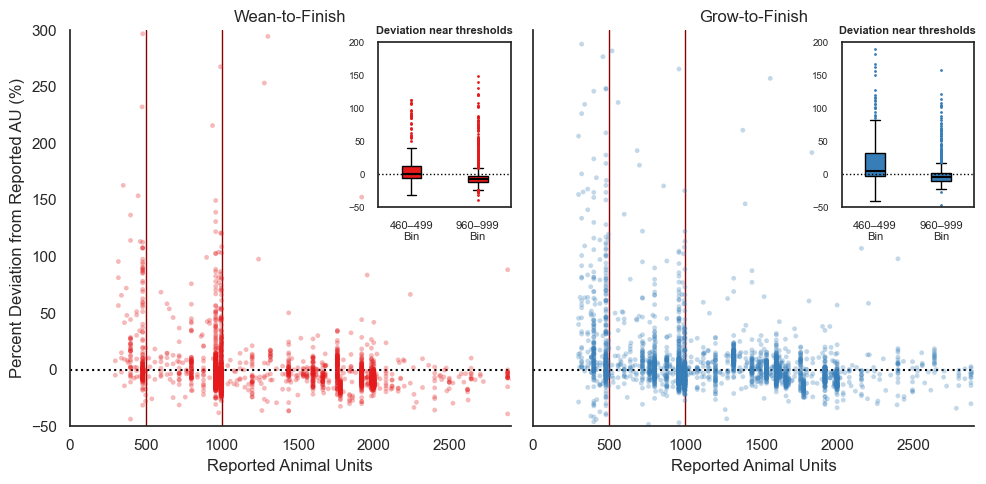

In [24]:
# Create relative deviation variable
facilities_swine["relative_deviation"] = (
    (
        facilities_swine["estimated_animal_units"]
        - facilities_swine["reported_animal_units"]
    )
    / facilities_swine["reported_animal_units"]
) * 100


au_plot_limit = 2900
uncertainty = False

# Extract hue -> color mapping
hue_order = included_types
palette = sns.color_palette(n_colors=len(hue_order))
hue_color_map = dict(zip(hue_order, palette))

# Faceted scatter plot of relative deviation vs reported AUs
g = sns.lmplot(
    data=facilities_swine[
        facilities_swine.swine_cat_combined_label.isin(included_types)
    ],
    x="reported_animal_units",
    y="relative_deviation",
    col="swine_cat_combined_label",
    hue="swine_cat_combined_label",
    col_wrap=2,
    height=5,
    scatter_kws={"alpha": 0.3, "s": 12, "edgecolor": "none", "zorder": 2},
    fit_reg=False,
    palette=palette,
)

# Optional: add vertical error bars for uncertainty (disabled here)
if uncertainty:
    for ax, name in zip(g.axes.flat, included_types):
        facet_data = facilities_swine[facilities_swine.swine_cat_combined_label == name]
        yerr = (
            np.array(
                [
                    facet_data["estimated_animal_units"]
                    - facet_data["estimated_animal_units_lower"],
                    facet_data["estimated_animal_units_upper"]
                    - facet_data["estimated_animal_units"],
                ]
            )
            / facet_data["reported_animal_units"]
        )
        ax.errorbar(
            x=facet_data["reported_animal_units"],
            y=facet_data["relative_deviation"],
            yerr=yerr,
            fmt="none",
            ecolor=hue_color_map[name],
            alpha=0.2,
            elinewidth=0.8,
            zorder=1,
        )

# Add horizontal zero-deviation line
for ax in g.axes.flat:
    ax.axhline(
        y=0,
        color="black",
        linestyle="dotted",
        zorder=0,
    )

# Add vertical regulatory thresholds (on x-axis)
for ax in g.axes.flat:
    for threshold, label in thresholds.items():
        ax.axvline(
            threshold,
            color="darkred",
            lw=1,
            label=f"{label} ({threshold} AUs)",
            zorder=0,
        )

# Add zoomed-in inset boxplots per facet
for ax, name in zip(g.axes.flat, included_types):
    facet_data = facilities_swine[facilities_swine.swine_cat_combined_label == name]
    zoom_data = facet_data[
        (
            (facet_data["reported_animal_units"] >= 460)
            & (facet_data["reported_animal_units"] <= 499)
        )
        | (
            (facet_data["reported_animal_units"] >= 960)
            & (facet_data["reported_animal_units"] <= 999)
        )
    ].copy()

    zoom_data["au_band"] = np.where(
        zoom_data["reported_animal_units"] < 500, "460–499\nBin", "960–999\nBin"
    )

    axins = inset_axes(
        ax,
        width="30%",
        height="41.74%",
        loc="upper right",
        bbox_to_anchor=(0, -0.03, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0,
    )

    sns.boxplot(
        y="relative_deviation",
        x="au_band",
        data=zoom_data,
        order=["460–499\nBin", "960–999\nBin"],
        ax=axins,
        width=0.3,
        showcaps=True,
        boxprops={
            "facecolor": hue_color_map[name],
            "linewidth": 1,
            "edgecolor": "black",
        },
        whiskerprops={"linewidth": 1, "color": "black"},
        capprops={"linewidth": 1, "color": "black"},
        medianprops={"color": "black", "linewidth": 1.5},
        flierprops={
            "markerfacecolor": hue_color_map[name],
            "markeredgecolor": hue_color_map[name],
            "markersize": 1,
        },
    )

    axins.axhline(0, color="black", linewidth=1, linestyle="dotted")
    axins.set_title("Deviation near thresholds", fontsize=8, fontweight="bold")
    axins.set_xlabel("")
    axins.set_ylabel("")
    axins.tick_params(axis="x", labelsize=8)
    axins.tick_params(axis="y", labelsize=7)
    axins.set_ylim(-50, 200)  # Adjust if needed

# set limits
for ax in g.axes.flat:
    ax.set_ylim(-50, 300)
    ax.set_xlim(0, au_plot_limit)

# Final formatting
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Reported Animal Units", "Percent Deviation from Reported AU (%)")
g.tight_layout()


# Save + show
plt.savefig(
    f"output/plots/relative_deviation_by_category_uncertainty{uncertainty}.png", dpi=300
)
plt.show()

<h2>Permutation Test</h2>

Threshold bin size is 245
Control bin size is 230
Size of Threshold Set is: 2934
Size of Control Set is: 3591
Expected Null Ratio: 1
Threshold bin size is 146
Control bin size is 119
Size of Threshold Set is: 2934
Size of Control Set is: 3591
Expected Null Ratio: 1
Threshold bin size is 245
Control bin size is 230
Size of Threshold Set is: 2934
Size of Control Set is: 3591
Expected Null Ratio: 1


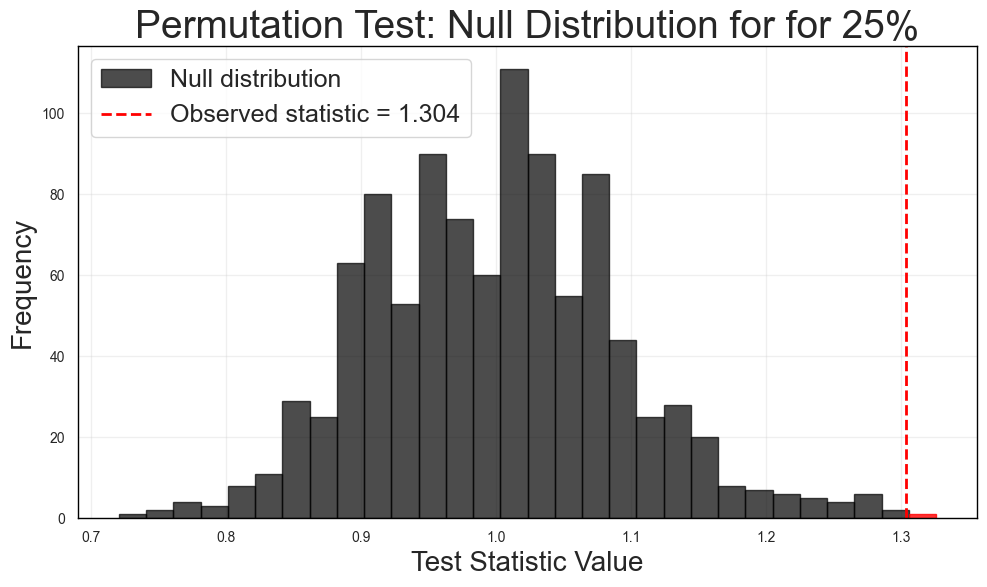

for 25%Test ratio is 1.3037476660442786
for 25%Null ratio of >50 percent is 0.9992901363803081
for 25%P value is 0.998
KstestResult(statistic=0.6962737450306065, pvalue=0.0, statistic_location=1121.2756958299512, statistic_sign=1)


<Figure size 640x480 with 0 Axes>

Threshold bin size is 146
Control bin size is 119
Size of Threshold Set is: 2934
Size of Control Set is: 3591
Expected Null Ratio: 1


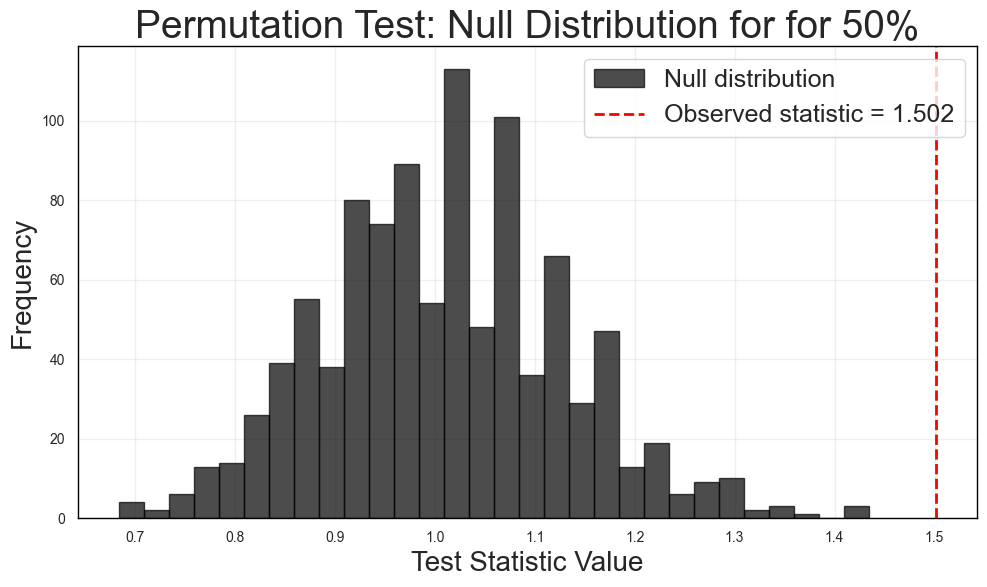

for 50%Test ratio is 1.5016239624684231
for 50%Null ratio of >50 percent is 1.0085421183369603
for 50%P value is 1.0
KstestResult(statistic=0.6962737450306065, pvalue=0.0, statistic_location=1121.2756958299512, statistic_sign=1)


<Figure size 640x480 with 0 Axes>

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(
    style="whitegrid",
    context="notebook",
    rc={
        "axes.edgecolor": "black",
        "axes.linewidth": 1,
        "grid.alpha": 0.3,
        "axes.axisbelow": True,
        "font.size": 25,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 13,
    },
)

np.random.seed(42)
type_swine = ['Wean-to-Finish', 'Grow-to-Finish']

data = facilities_swine[facilities_swine['swine_cat_combined_label'] == type_swine[0]]
x1 = data['reported_animal_units']
y1 = data['estimated_animal_units']

data2 = facilities_swine[facilities_swine['swine_cat_combined_label'] == type_swine[1]]
x2 = data2['reported_animal_units']
y2 = data2['estimated_animal_units']

x = pd.concat([x1,x2])
y = pd.concat([y1,y2])

twentyfive_underreport = 1.25
fifty_underreport = 1.5

percentages = [twentyfive_underreport, fifty_underreport]

threshold_ranges = [(460, 500), (960, 1000)]
threshold_mask = np.zeros_like(x, dtype=bool)
for lower, upper in threshold_ranges:
    threshold_mask |= (x >= lower) & (x < upper)

threshold_set = y[threshold_mask]
threshold_set_reported = x[threshold_mask]

control_mask = ~threshold_mask
# exclude_ranges = [(420, 460), (920, 960)]
# for lower, upper in exclude_ranges:
#     control_mask &= ~((x >= lower) & (x <= upper))  # Values in these ranges should also be excluded

control_set = y[control_mask]
control_set_reported = x[control_mask]

for j in range(0,2):
    condition = (threshold_set >= percentages[j] * threshold_set_reported)
    threshold_bin = np.sum(condition)
    threshold_set_size = np.size(threshold_set)

    condition2 = (control_set >= percentages[j] * control_set_reported)
    control_set_size = np.size(control_set)
    control_bin = np.sum(condition2)

    print("Threshold bin size is " + str(threshold_bin))
    print("Control bin size is " + str(control_bin))
    
    print("Size of Threshold Set is: " + str(np.size(threshold_set)))
    print("Size of Control Set is: " + str(np.size(control_set)))

    print('Expected Null Ratio: ' + str(1))
    # print('Expected Null Ratio: ' + str(np.size(control_set)/np.size(threshold_set)))

    test_ratio = (control_bin/control_set_size)/(threshold_bin/threshold_set_size) #Ratio of outliers per set

    threshold_pairs = np.column_stack((threshold_set_reported, threshold_set))  # Shape (3, 2)
    control_pairs = np.column_stack((control_set_reported, control_set))
    permutation_test_set = np.concatenate((threshold_pairs, control_pairs))

    test_ratios = np.zeros(1000)


    for i in range(0,1000):
        selected_indices = np.random.choice(permutation_test_set.shape[0], size=np.size(threshold_set), replace=False)
        mask = np.zeros(permutation_test_set.shape[0], dtype=bool)
        mask[selected_indices] = True
        leftover_indices = np.where(~mask)[0]

        new_threshold_set = permutation_test_set[selected_indices]
        new_control_set = permutation_test_set[leftover_indices]

        condition_new = (new_threshold_set[:,1] >= percentages[j] * new_threshold_set[:,0])
        condition2_new = (new_control_set[:,1] >= percentages[j] * new_control_set[:,0])

        new_threshold_bin = np.sum(condition_new)
        new_control_bin = np.sum(condition2_new)

        new_ratio = (new_control_bin/control_set_size)/(new_threshold_bin/threshold_set_size)

        test_ratios[i] = new_ratio

    # plt.hist(test_ratios)
    # plt.title()

    #Calculate p value
    condition3 = test_ratios<test_ratio
    p_value = np.sum(condition3)/np.size(test_ratios)

    #Making the histograms
    # Your data (replace with your actual values)
    permutation_statistics = test_ratios
    observed_statistic = test_ratio

    # Create the histogram
    import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(
    style="whitegrid",
    context="notebook",
    rc={
        "axes.edgecolor": "black",
        "axes.linewidth": 1,
        "grid.alpha": 0.3,
        "axes.axisbelow": True,
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    },
)

np.random.seed(42)
type_swine = ['Wean-to-Finish', 'Grow-to-Finish']

data = facilities_swine[facilities_swine['swine_cat_combined_label'] == type_swine[0]]
x1 = data['reported_animal_units']
y1 = data['estimated_animal_units']

data2 = facilities_swine[facilities_swine['swine_cat_combined_label'] == type_swine[1]]
x2 = data2['reported_animal_units']
y2 = data2['estimated_animal_units']

x = pd.concat([x1,x2])
y = pd.concat([y1,y2])

twentyfive_underreport = 1.25
fifty_underreport = 1.5

percentages = [twentyfive_underreport, fifty_underreport]

threshold_ranges = [(460, 500), (960, 1000)]
threshold_mask = np.zeros_like(x, dtype=bool)
for lower, upper in threshold_ranges:
    threshold_mask |= (x >= lower) & (x < upper)

threshold_set = y[threshold_mask]
threshold_set_reported = x[threshold_mask]

control_mask = ~threshold_mask
# exclude_ranges = [(420, 460), (920, 960)]
# for lower, upper in exclude_ranges:
#     control_mask &= ~((x >= lower) & (x <= upper))  # Values in these ranges should also be excluded

control_set = y[control_mask]
control_set_reported = x[control_mask]

for j in range(0,2):
    condition = (threshold_set >= percentages[j] * threshold_set_reported)
    threshold_bin = np.sum(condition)
    threshold_set_size = np.size(threshold_set)

    condition2 = (control_set >= percentages[j] * control_set_reported)
    control_set_size = np.size(control_set)
    control_bin = np.sum(condition2)

    print("Threshold bin size is " + str(threshold_bin))
    print("Control bin size is " + str(control_bin))
    
    print("Size of Threshold Set is: " + str(np.size(threshold_set)))
    print("Size of Control Set is: " + str(np.size(control_set)))

    print('Expected Null Ratio: ' + str(1))
    # print('Expected Null Ratio: ' + str(np.size(control_set)/np.size(threshold_set)))

    test_ratio = (threshold_bin/threshold_set_size)/(control_bin/control_set_size) #Ratio of outliers per set

    threshold_pairs = np.column_stack((threshold_set_reported, threshold_set))  # Shape (3, 2)
    control_pairs = np.column_stack((control_set_reported, control_set))
    permutation_test_set = np.concatenate((threshold_pairs, control_pairs))

    test_ratios = np.zeros(1000)


    for i in range(0,1000):
        selected_indices = np.random.choice(permutation_test_set.shape[0], size=np.size(threshold_set), replace=False)
        mask = np.zeros(permutation_test_set.shape[0], dtype=bool)
        mask[selected_indices] = True
        leftover_indices = np.where(~mask)[0]

        new_threshold_set = permutation_test_set[selected_indices]
        new_control_set = permutation_test_set[leftover_indices]

        condition_new = (new_threshold_set[:,1] >= percentages[j] * new_threshold_set[:,0])
        condition2_new = (new_control_set[:,1] >= percentages[j] * new_control_set[:,0])

        new_threshold_bin = np.sum(condition_new)
        new_control_bin = np.sum(condition2_new)

        new_ratio = (new_threshold_bin/threshold_set_size)/(new_control_bin/control_set_size)

        test_ratios[i] = new_ratio

    # plt.hist(test_ratios)
    # plt.title()

    #Calculate p value
    condition3 = test_ratios<test_ratio
    p_value = np.sum(condition3)/np.size(test_ratios)

    #Making the histograms
    # Your data (replace with your actual values)
    permutation_statistics = test_ratios
    observed_statistic = test_ratio

    # Create the histogram
    plt.figure(figsize=(10, 6))

     # Plot the histogram - matplotlib will create bins automatically
    counts, bins, patches = plt.hist(permutation_statistics, bins=30, alpha=0.7,
                                    color='black', edgecolor='black',
                                    label='Null distribution')

    # Add vertical line for observed statistic
    plt.axvline(observed_statistic, color='red', linestyle='--', linewidth=2,
                label=f'Observed statistic = {observed_statistic:.3f}')

    # Shade the rejection region (two-tailed test)
    # Find which bars to color red
    for i, (patch, bin_left, bin_right) in enumerate(zip(patches, bins[:-1], bins[1:])):
        bin_center = (bin_left + bin_right) / 2
        if abs(bin_center) >= abs(observed_statistic):
            patch.set_color('red')
            patch.set_alpha(0.8)

    # Labels and formatting
    plt.xlabel('Test Statistic Value',fontsize=20)
    plt.ylabel('Frequency',fontsize=20)
    pcts = ['for 25%', 'for 50%']
    plt.title(f'Permutation Test: Null Distribution for '+str(pcts[j]) ,  fontsize=28)
              #\n(p-value = {p_value:.4f})')
    plt.legend(fontsize=18)
    plt.grid(True, alpha=0.3)

    # Add text annotation for p-value
    # plt.text(0.05, 0.95, f'p = {p_value:.4f}', transform=plt.gca().transAxes,
            # bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
            # verticalalignment='top', fontsize=12)

    plt.tight_layout()
    plt.show()

    # Optional: Save the figure
    plt.savefig('permutation_test_histogram_{percentages[j]}.png', dpi=300, bbox_inches='tight')


    
    print(pcts[j]+'Test ratio is ' + str(test_ratio))
    print(pcts[j]+"Null ratio of >50 percent is " +str(np.mean(test_ratios)))

    # print(test_ratios)
    
    print(pcts[j]+"P value is " + str(p_value))

    print(stats.kstest(threshold_set,control_set))
    plt.show()

    # plt.savefig('permutation_test_histogram_{percentages[j]}.png', dpi=300, bbox_inches='tight')


    
    # print(pcts[j]+'Test ratio is ' + str(test_ratio))
    # print(pcts[j]+"Null ratio of >50 percent is " +str(np.mean(test_ratios)))
    # print(pcts[j]+"P value is " + str(p_value))
    # print(stats.kstest(threshold_set,control_set))

<h2>Difference Between Estimated and Reported with Error Bars</h2>

/var/folders/xj/nk_7447d20gcrbftkc9p3hk40000gn/T/ipykernel_67865/940621799.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["swine_cat_combined_label", "reported_bin"])
/var/folders/xj/nk_7447d20gcrbftkc9p3hk40000gn/T/ipykernel_67865/940621799.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_ci)


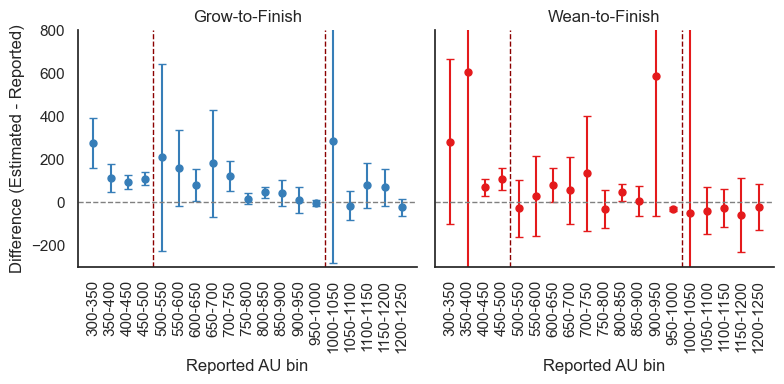

In [29]:
# Define difference
facilities_swine["diff_au"] = (
    facilities_swine["estimated_animal_units"]
    - facilities_swine["reported_animal_units"]
)

# Define bins
bins = np.arange(300, 1300, 50)
labels = [f"{b}-{b+50}" for b in bins[:-1]]
facilities_swine["reported_bin"] = pd.cut(
    facilities_swine["reported_animal_units"], bins=bins, labels=labels, right=False
)


# Summary with CI
def summarize_ci(group):
    n = len(group)
    mean = group["diff_au"].mean()
    stderr = sem(group["diff_au"], nan_policy="omit")
    ci95 = stderr * t.ppf(0.975, df=n - 1) if n > 1 else np.nan
    return pd.Series({"mean_diff": mean, "ci95": ci95})


summary_df = (
    facilities_swine.dropna(subset=["reported_bin"])
    .groupby(["swine_cat_combined_label", "reported_bin"])
    .apply(summarize_ci)
    .reset_index()
)

# Plot with colored points + error bars
g = sns.FacetGrid(
    summary_df,
    col="swine_cat_combined_label",
    col_wrap=2,
    height=4,
    sharey=True,
)

for ax, (name, subdf) in zip(
    g.axes.flat, summary_df.groupby("swine_cat_combined_label")
):
    x = np.arange(len(subdf))
    y = subdf["mean_diff"].values
    yerr = subdf["ci95"].values
    color = hue_color_map[name]

    ax.errorbar(
        x,
        y,
        yerr=yerr,
        fmt="o",
        color=color,
        capsize=3,
        label=name,
        markersize=5,
    )

    # Add horizontal line at zero
    ax.axhline(0, color="gray", linestyle="--", lw=1)

    # Add vertical lines at bins containing 500 and 1000
    threshold_bins = {"500": "500-550", "1000": "1000-1050"}
    for thresh_label in threshold_bins.values():
        if thresh_label in subdf["reported_bin"].values:
            idx = (
                subdf[subdf["reported_bin"] == thresh_label].index[0]
                - subdf.index[0]
                - 0.5
            )
            ax.axvline(x=idx, color="darkred", linestyle="--", lw=1)

    # Rotate x-axis labels
    ax.set_xticks(x)
    ax.set_xticklabels(subdf["reported_bin"], rotation=90)
    ax.set_ylabel("Estimated - Reported AUs")
    ax.set_ylim(-300, 800)

# Final formatting
g.set_titles("{col_name}")
g.set_axis_labels("Reported AU bin", "Difference (Estimated - Reported)")
g.tight_layout()

plt.show()

/var/folders/xj/nk_7447d20gcrbftkc9p3hk40000gn/T/ipykernel_67865/2543789807.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/var/folders/xj/nk_7447d20gcrbftkc9p3hk40000gn/T/ipykernel_67865/2543789807.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


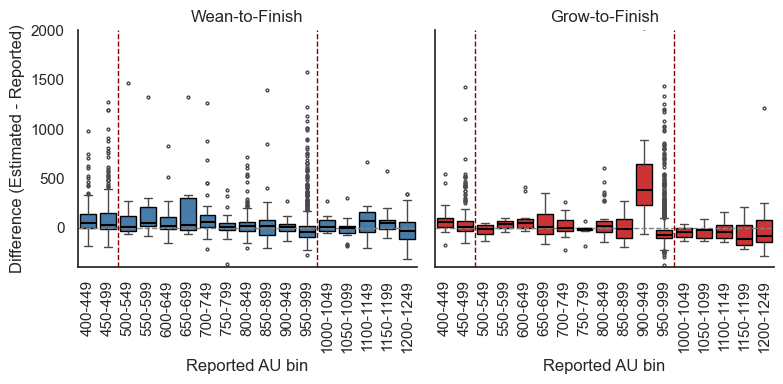

In [30]:
# Step 1: Create the difference column
facilities_swine["diff_au"] = (
    facilities_swine["estimated_animal_units"]
    - facilities_swine[
        "reported_animal_units"
    ]  # / facilities_swine["reported_animal_units"]
)

# Step 2: Bin reported animal units
bins = np.arange(400, 1300, 50)
labels = [f"{b}-{b+49}" for b in bins[:-1]]
facilities_swine["reported_bin"] = pd.cut(
    facilities_swine["reported_animal_units"], bins=bins, labels=labels, right=False
)

# Drop NA bins
plot_df = facilities_swine.dropna(subset=["reported_bin"])

# Step 4: Plot using seaborn FacetGrid and boxplot
g = sns.FacetGrid(
    plot_df,
    col="swine_cat_combined_label",
    col_wrap=2,
    height=4,
    sharey=True,
)

for ax, (name, subdf) in zip(g.axes.flat, plot_df.groupby("swine_cat_combined_label")):
    color = hue_color_map[name]

    sns.boxplot(
        data=subdf,
        x="reported_bin",
        y="diff_au",
        ax=ax,
        color=color,
        fliersize=2,
        linewidth=1,
        boxprops={"edgecolor": "black"},
        medianprops={"color": "black", "linewidth": 1.5},
        whiskerprops={"linewidth": 1},
        capprops={"linewidth": 1},
    )

    # Rotate x-axis tick labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

    # Horizontal line at 0
    ax.axhline(0, color="gray", linestyle="--", lw=1)

    # Vertical lines at bins including thresholds
    threshold_bins = {"500": "500-549", "1000": "1000-1049"}
    for thresh_label in threshold_bins.values():
        if thresh_label in subdf["reported_bin"].values:
            idx = (
                subdf["reported_bin"].cat.categories.tolist().index(thresh_label) - 0.5
            )
            ax.axvline(x=idx, color="darkred", linestyle="--", lw=1)

    ax.set_ylabel("Estimated - Reported AUs")
    ax.set_ylim(-400, 2000)

# Final formatting
g.set_titles("{col_name}")
g.set_axis_labels("Reported AU bin", "Difference (Estimated - Reported)")
g.tight_layout()


plt.show()

In [ ]:
facilities_swine_thresholds = facilities_swine[
    (
        (
            (facilities_swine["reported_animal_units"] >= 460)
            & (facilities_swine["reported_animal_units"] <= 499)
        )
        & (facilities_swine["estimated_animal_units"] > 500)
    )
    | (
        (
            (facilities_swine["reported_animal_units"] >= 960)
            & (facilities_swine["reported_animal_units"] <= 999)
        )
        & (facilities_swine["estimated_animal_units"] > 1000)
    )
].copy()


# Step 2: Aggregate CH4 emissions by swine category
methane_grouped = (
    facilities_swine_thresholds.groupby("swine_cat_combined_label")
    .agg({"reported_ch4_total": "sum", "estimated_ch4_total": "sum", "estimated_ch4_total_lower": "sum", "estimated_ch4_total_upper": "sum"})
    .reset_index()
)

# Step 3: Melt to long format
methane_melted = methane_grouped.melt(
    id_vars="swine_cat_combined_label",
    value_vars=["reported_ch4_total", "estimated_ch4_total"],
    var_name="source",
    value_name="total_ch4",
)

methane_melted["total_ch4"] = methane_melted["total_ch4"] / 1000

# Clean label names
methane_melted["source"] = methane_melted["source"].map(
    {"reported_ch4_total": "Reported", "estimated_ch4_total": "Estimated"}
)

# Calculate error bars using the upper and lower bounds
# Error bars: lower bound and upper bound deviations from the estimated value
methane_grouped["lower_error"] = (methane_grouped["estimated_ch4_total"] - methane_grouped["estimated_ch4_total_lower"]) / 1000
methane_grouped["upper_error"] = (methane_grouped["estimated_ch4_total_upper"] - methane_grouped["estimated_ch4_total"]) / 1000

# Step 4: Set custom colors
custom_palette = {"Reported": "purple", "Estimated": "green"}

# Step 5: Create the faceted barplot
g = sns.catplot(
    data=methane_melted,
    x="source",
    y="total_ch4",
    hue="source",
    col="swine_cat_combined_label",
    kind="bar",
    palette=custom_palette,
    col_order=included_types,
    alpha=0.5,
    height=4,  # shorter
    aspect=1.3,  # wider
    sharey=True,
)

for ax in g.axes.flat:
    for bar in ax.containers:
        for patch in bar:
            fc = patch.get_facecolor()
            patch.set_edgecolor(fc)
            patch.set_linewidth(1.5)  # optional: adjust edge thickness

# Step 6: Add error bars to the "Estimated" bars
# Get the list of hue categories in order used by seaborn
hue_order = methane_melted["source"].unique().tolist()

# Find the index of 'Estimated' in hue_order
estimated_idx = hue_order.index("Estimated")

for ax in g.axes.flat:
    # Each ax has .containers, each container is all bars for one hue level
    estimated_container = ax.containers[estimated_idx]  # container for 'Estimated' bars
    
    for i, bar in enumerate(estimated_container):
        height = bar.get_height()
        lower = methane_grouped["lower_error"].iloc[i]
        upper = methane_grouped["upper_error"].iloc[i]
        yerr = [[lower], [upper]]
        ax.errorbar(
            bar.get_x() + bar.get_width() / 2,
            height,
            yerr=yerr,
            fmt="none",
            color="green",
            capsize=5,
            elinewidth=2,
            capthick=2,
            zorder=10,  # on top
        )
        
# Final formatting
g.set_axis_labels("Emission Source", "Total CH4 Emissions (tons/year)")
g.set_titles(col_template="{col_name}")
g.set_xticklabels(rotation=0)

plt.tight_layout()
plt.savefig(
    "output/plots/ch4_reported_vs_estimated_combined_underreporting.png", dpi=300
)
plt.show()

In [ ]:
print(methane_melted)
print(methane_melted.groupby("source").agg({"total_ch4": "sum"}))

print(methane_melted.groupby("source").agg({"total_ch4": "sum"}))
methane_melted.groupby("source").agg({"total_ch4": "sum"}).iloc[
    0
] / methane_melted.groupby("source").agg({"total_ch4": "sum"}).iloc[1]

In [ ]:
g = sns.lmplot(
    data=facilities_swine[
        facilities_swine.swine_cat_combined_label.isin(included_types)
    ],
    x="reported_animal_units",
    y="estimated_animal_units",
    col="swine_cat_combined_label",
    hue="parcel_count",
    col_wrap=2,
    height=5,
    scatter_kws={"alpha": 0.3, "s": 30, "edgecolor": "none"},
    fit_reg=False,
)

# Calculate and add correlation coefficients for each facet
for ax, name in zip(g.axes.flat, included_types):
    # Get data for this facet
    facet_data = facilities_swine[facilities_swine.swine_cat_combined_label == name]
    corr = facet_data["reported_animal_units"].corr(
        facet_data["estimated_animal_units"]
    )
    # Add correlation text to top left corner
    ax.text(
        0.01,
        0.99,
        f"r = {corr:.2f}",
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold",
        verticalalignment="top",
    )

# add xy line
for ax in g.axes.flat:
    ax.plot(
        [0, au_plot_limit * 2],
        [0, au_plot_limit * 2],
        color="black",
        linestyle="dotted",
    )

# add xlim
for ax in g.axes.flat:
    ax.set_xlim(0, au_plot_limit * 2)
    ax.set_ylim(0, au_plot_limit * 2)

# add vertical lines
for ax in g.axes.flat:
    for threshold, label in thresholds.items():
        ax.axvline(
            threshold,
            color="darkred",
            # linestyle="--",
            lw=1,
            label=f"{label} ({threshold} AUs)",
        )

for ax in g.axes.flat:
    ax.axhline(0, color="black", linestyle="--", alpha=0.7)

g.set_titles(col_template="{col_name}")

# add axis legends
g.set_axis_labels("Reported Animal Units", "Estimated Animal Units")
g.tight_layout()
plt.show()

# Figure: Reported - Estimated

In [ ]:
g = sns.lmplot(
    data=facilities_swine[
        facilities_swine.swine_cat_combined_label.isin(included_types)
    ],
    x="reported_animal_units",
    y="animal_difference",
    col="swine_cat_combined_label",
    hue="swine_cat_combined_label",
    col_wrap=2,
    height=5,
    scatter_kws={"alpha": 0.3, "s": 30, "edgecolor": "none"},
    fit_reg=False,  # This removes the trend line
)

# add xlim
for ax in g.axes.flat:
    ax.set_xlim(0, au_plot_limit)

# add vertical lines
for ax in g.axes.flat:
    for threshold, label in thresholds.items():
        ax.axvline(
            threshold,
            color="darkred",
            # linestyle="--",
            lw=1,
            label=f"{label} ({threshold} AUs)",
        )

for ax in g.axes.flat:
    ax.axhline(0, color="black", linestyle="dotted", alpha=0.7)
    ax.set_ylim(-au_plot_limit / 2, au_plot_limit / 2)

g.set_titles(col_template="{col_name}")

# add axis legends
g.set_axis_labels("Reported Animal Units", "Difference (Reported - Estimated)")
g.tight_layout()
plt.savefig("output/plots/animal_difference.png", dpi=300)
plt.show()

# Reported vs. Estimated, Percent Reported

In [ ]:
facilities_swine["difference_percent"] = (
    facilities_swine["animal_difference"] / facilities_swine["reported_animal_units"]
)

g = sns.lmplot(
    data=facilities_swine[
        facilities_swine.swine_cat_combined_label.isin(included_types)
    ],
    x="reported_animal_units",
    y="difference_percent",
    col="swine_cat_combined_label",
    hue="swine_cat_combined_label",
    col_wrap=2,
    height=5,
    scatter_kws={"alpha": 0.3, "s": 30, "edgecolor": "none"},
    fit_reg=False,  # This removes the trend line
)

# add xlim
for ax in g.axes.flat:
    ax.set_xlim(0, au_plot_limit)

# add vertical lines
for ax in g.axes.flat:
    for threshold, label in thresholds.items():
        ax.axvline(
            threshold,
            color="darkred",
            # linestyle="--",
            lw=1,
            label=f"{label} ({threshold} AUs)",
        )

for ax in g.axes.flat:
    ax.axhline(0, color="black", linestyle="dotted", alpha=0.7)
    ax.set_ylim(-3, 0.9)

g.set_titles(col_template="{col_name}")

# add axis legends
g.set_axis_labels(
    "Reported Animal Units", "Difference (Reported - Estimated) / Reported"
)
g.tight_layout()
plt.savefig("output/plots/animal_difference.png", dpi=300)
plt.show()

# Test for difference in variance

In [ ]:
# Filter the two groups
group1 = facilities_swine[
    (facilities_swine["reported_animal_units"] >= 960)
    & (facilities_swine["reported_animal_units"] <= 1000)
]["animal_difference"]
group2 = facilities_swine[
    (facilities_swine["reported_animal_units"] >= 1001)
    & (facilities_swine["reported_animal_units"] <= 1200)
]["animal_difference"]

# Print number of observations in each group
n1, n2 = len(group1), len(group2)
print(f"Number of observations in Group 1 (900-1000 animal units): {n1}")
print(f"Number of observations in Group 2 (1001-1100 animal units): {n2}")

# Levene's test (for variance equality, robust to non-normality)
levene_stat, levene_p = stats.levene(group1, group2, center="median")

# Bartlett’s test (for variance equality, assumes normality)
bartlett_stat, bartlett_p = stats.bartlett(group1, group2)

# Fligner's test (for variance equality, robust to non-normality)
flig_stat, flig_p = fligner(group1, group2)

print(f"\nLevene's Test: Statistic={levene_stat:.4f}, p-value={levene_p:.4f}")
print(f"Bartlett's Test: Statistic={bartlett_stat:.4f}, p-value={bartlett_p:.4f}")
print(f"Fligner's Test: Statistic={flig_stat:.4f}, p-value={flig_p:.4f}")

# Interpretation
if levene_p < 0.05:
    print("Levene's test suggests variances are significantly different.")
else:
    print("Levene's test suggests variances are not significantly different.")

if bartlett_p < 0.05:
    print("Bartlett's test suggests variances are significantly different.")
else:
    print("Bartlett's test suggests variances are not significantly different.")

In [ ]:
# Placebo plot for variance test

# Define placebo thresholds
bandwidth = 40
placebo_ts = np.arange(300, 2500, 2)
# Filter out thresholds within bunching windows
bunching_ranges = [(460, 500), (960, 1000)]


def is_in_bunching_region(t, ranges):
    return any(low <= t <= high for (low, high) in ranges)


placebo_stats = []
for t in placebo_ts:
    if is_in_bunching_region(t, bunching_ranges):
        continue

    group_left = facilities_swine[
        (facilities_swine["reported_animal_units"] >= t - bandwidth)
        & (facilities_swine["reported_animal_units"] <= t - 1)
    ]["animal_difference"]

    group_right = facilities_swine[
        (facilities_swine["reported_animal_units"] >= t + 1)
        & (facilities_swine["reported_animal_units"] <= t + bandwidth)
    ]["animal_difference"]

    if len(group_left) > 5 and len(group_right) > 5:
        stat, _ = fligner(group_left, group_right)
        placebo_stats.append(stat)

# Plot
plt.figure(figsize=(6, 5))
plt.hist(placebo_stats, bins=20, alpha=0.7, label="Placebo Distribution", color="grey")
plt.axvline(
    flig_stat,
    color="red",
    linestyle="--",
    label=f"True Threshold Stat = {flig_stat:.2f}",
)
plt.xlabel("Fligner Test Statistic")
plt.ylabel("Count")
plt.title("Placebo Distribution of Variance Tests (Excluding Bunching Regions)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("output/plots/placebo_variance_test.png", dpi=300)
plt.show()


# Empirical p-value
emp_p = (np.array(placebo_stats) >= flig_stat).mean()
print(f"Empirical p-value: {emp_p:.3f}")

# Figure: model fit, reported vs. predicted animal units

In [ ]:
# specify model
EPSILON = 1e-6

# Apply log transformation with small constant
facilities_swine["log_reported_animal_units"] = np.log(
    facilities_swine["reported_animal_units"] + EPSILON
)
facilities_swine["log_estimated_animal_units"] = np.log(
    facilities_swine["estimated_animal_units"] + EPSILON
)
facilities_swine["log_barn_area_sqm"] = np.log(
    facilities_swine["barn_area_sqm"] + EPSILON
)

# Define exclusion ranges as a list of tuples (lower_bound, upper_bound)
exclusion_aus = [(400, 500), (900, 1000), (1900, 2000)]

conditions = [
    (facilities_swine["reported_animal_units"] >= low)
    & (facilities_swine["reported_animal_units"] <= high)
    for low, high in exclusion_aus
]
combined_condition = reduce(operator.or_, conditions)


# Filter the DataFrame to exclude the specified ranges
facilities_swine_train = facilities_swine[~combined_condition].copy()

In [ ]:
# Fit OLS model with log transformation
model_log = smf.ols(
    "log_reported_animal_units ~ log_barn_area_sqm * swine_cat_combined",
    data=facilities_swine_train,
)
results_log = model_log.fit()

# Save predictions and residuals
facilities_swine_train["log_fitted"] = results_log.fittedvalues
facilities_swine_train["log_residuals"] = results_log.resid
facilities_swine_train["fitted"] = (
    np.exp(facilities_swine_train["log_fitted"]) - EPSILON
)
facilities_swine_train["residuals"] = (
    facilities_swine_train["reported_animal_units"] - facilities_swine_train["fitted"]
)

# Predict on the full dataset
facilities_swine["log_estimated_animal_units"] = np.log(
    facilities_swine["estimated_animal_units"] + EPSILON
)
facilities_swine["log_fitted"] = results_log.predict(facilities_swine)
facilities_swine["log_residuals"] = (
    facilities_swine["log_reported_animal_units"] - facilities_swine["log_fitted"]
)

# Transform predictions back to original scale
facilities_swine["fitted"] = np.exp(facilities_swine["log_fitted"]) - EPSILON
facilities_swine["residuals"] = (
    facilities_swine["reported_animal_units"] - facilities_swine["fitted"]
)
facilities_swine["residuals_relative"] = (
    facilities_swine["residuals"] / facilities_swine["reported_animal_units"]
)

# Display model summary
print(results_log.summary())

In [ ]:
# Create the lmplot
g = sns.lmplot(
    data=facilities_swine_train[
        facilities_swine_train.swine_cat_combined_label.isin(included_types)
    ],
    x="reported_animal_units",
    y="fitted",
    col="swine_cat_combined_label",
    hue="swine_cat_combined_label",
    col_wrap=2,
    height=5,
    scatter_kws={"alpha": 0.3, "s": 30, "edgecolor": "none"},
    line_kws={"color": "darkblue", "alpha": 0.5},
    fit_reg=False,
)

# Calculate and add correlation coefficients for each facet
for ax, name in zip(g.axes.flat, included_types):
    # Get data for this facet
    facet_data = facilities_swine_train[
        facilities_swine_train.swine_cat_combined_label == name
    ]
    corr = facet_data["reported_animal_units"].corr(facet_data["fitted"])
    # Add correlation text to top left corner
    ax.text(
        0.01,
        0.99,
        f"r = {corr:.2f}",
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold",
        verticalalignment="top",
    )
    # set limits
    ax.set_xlim(200)
    ax.set_ylim(200)
    # add x=y line
    ax.plot(
        ax.get_xlim(), ax.get_xlim(), linestyle="dotted", color="black", linewidth=1
    )
    # Add red line and shading for the excluded areas on each facet.
    for threshold, label in thresholds.items():
        ax.axvline(threshold, color="darkred", linestyle="--")
    for i, (low, high) in enumerate(exclusion_aus):
        label = "Excluded Training Range" if i == 0 else None
        ax.axvspan(
            low,
            high,
            facecolor="red",
            alpha=0.1,
            edgecolor="none",
            label=label,
        )
    # add log scale axis, add lines and dont abbreviate axis labels with 10^
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Reported Animal Units")
    ax.set_ylabel("Fitted Values")
    ax.axhline(1, color="black", linestyle="--", alpha=0.7)
    ax.axvline(1, color="black", linestyle="--", alpha=0.7)

# Set the titles for each facet.
g.set_titles(col_template="{col_name}")

# Set axis labels.
g.set_axis_labels("Reported Animal Units", "Fitted Values")

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save and display the plot.
plt.savefig("output/plots/training_fit_regression.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure: Residual plot, reported vs. residual animal units

In [ ]:
g = sns.lmplot(
    data=facilities_swine[
        facilities_swine.swine_cat_combined_label.isin(included_types)
    ],
    x="reported_animal_units",
    y="residuals",
    col="swine_cat_combined_label",
    hue="swine_cat_combined_label",
    col_wrap=2,
    height=5,
    scatter_kws={"alpha": 0.3, "s": 30, "edgecolor": "none"},
    fit_reg=False,  # This removes the trend line
)

# add xlim
for ax in g.axes.flat:
    ax.set_xlim(0, au_plot_limit)
    ax.set_ylim(-au_plot_limit, au_plot_limit)

# Add shading for the excluded areas on each facet.
for ax in g.axes.flat:
    for i, (low, high) in enumerate(exclusion_aus):
        # Add label only for the first shaded region to avoid duplicate legend entries.
        label = "Excluded Training Range" if i == 0 else None
        ax.axvspan(
            low,
            high,
            facecolor="red",
            alpha=0.1,
            edgecolor="none",
            label=label,
        )

# Add vertical threshold lines with labels on each facet.
# (Assuming 'thresholds' is a dictionary, e.g., {500: "Threshold A", 1000: "Threshold B", ...})
for ax in g.axes.flat:
    for threshold, label in thresholds.items():
        ax.axvline(threshold, color="darkred", linestyle="--", lw=2)

# Set the titles for each facet.
g.set_titles(col_template="{col_name}")

for ax in g.axes.flat:
    ax.axhline(0, color="black", linestyle="dotted", alpha=0.7)

# add axis legends
g.set_axis_labels("Reported Animal Units", "Model residuals")
g.tight_layout()
plt.savefig("output/plots/residuals_by_reported.png", dpi=300)
plt.show()

# Histogram, Estimated vs Reported pollutants

In [ ]:
facilities_melt = facilities_swine.melt(
    value_vars=[
        "reported_ch4_total",
        "estimated_ch4_total",
        "reported_n2o_total",
        "estimated_n2o_total",
    ],
    var_name="measure_type",
    value_name="value",
)

facilities_melt["category"] = facilities_melt["measure_type"].apply(
    lambda x: "Estimated" if "estimated" in x else "Reported"
)

# Create a new column for the pollutant type
facilities_melt["pollutant_type"] = facilities_melt["measure_type"].apply(
    lambda x: x.replace("estimated_", "").replace("reported_", "")
)

In [ ]:
# generate bar plots
for p in ["ch4_total", "n2o_total"]:
    fig, ax = plt.subplots(figsize=(4, 4))
    sns.barplot(
        data=facilities_melt[facilities_melt["pollutant_type"] == p],
        x="category",
        y="value",
        hue="category",
        ax=ax,
    )

    ax.set_ylabel(f"{p.replace('_', ' ').capitalize()} (kg/year)")
    ax.set_xlabel("")

    plt.tight_layout()
    plt.savefig(f"output/plots/pollutant_{p}_barplot.png", dpi=300)
    plt.show()

# Map plots

In [ ]:
tracts = gpd.read_postgis(
    "SELECT id as tract_id, population, geometry from processed.census_tracts",
    s.get_engine(),
    geom_col="geometry",
)

## Map 1: Permit locations

In [ ]:
# plot permit locations
facility_permits = facilities_swine[["facility_id", "permit_geoms"]].copy()


# explode permit ids and geometries
facility_permits = facility_permits.explode("permit_geoms")
# convert permit_geoms to geometry
facility_permits["permit_geoms"] = facility_permits["permit_geoms"].apply(
    lambda x: wkt.loads(x)
)

gdf = gpd.GeoDataFrame(facility_permits, geometry="permit_geoms")
gdf.crs = facilities_swine.crs

fig, ax = plt.subplots(figsize=(10, 7))
tracts.plot(ax=ax, color="lightgrey", edgecolor="black", alpha=0.5)
gdf.plot(ax=ax, markersize=5, alpha=0.5)
ax.axis("off")
plt.tight_layout()
plt.savefig("output/plots/permit_locations.png", dpi=300)

In [ ]:
# combine tracts and facilities
# merge tracts and facilities based on facility centroid
facilities_swine_plot = facilities_swine.copy()
facilities_swine_plot["facility_centroid"] = facilities_swine.geometry.centroid
facilities_swine_plot = facilities_swine_plot.set_geometry("facility_centroid")

# spatial join
tracts_facilities = gpd.sjoin(tracts, facilities_swine_plot, how="left", op="contains")
# sum animal units per tract
tracts_facilities = tracts_facilities.groupby("tract_id").agg(
    reported_animal_units=("reported_animal_units", "sum"),
    population=("population", "first"),
    geometry=("geometry", "first"),
)
tracts_facilities = gpd.GeoDataFrame(tracts_facilities, geometry="geometry")
tracts_facilities.crs = tracts.crs

# calculate animal density per capita
tracts_facilities["animal_density"] = (
    tracts_facilities["reported_animal_units"] / tracts_facilities["population"]
)
tracts_facilities["animal_density"] = tracts_facilities["animal_density"].fillna(0)

# plot map
fig, ax = plt.subplots(figsize=(10, 7))

# Create the map plot
tracts_facilities.plot(
    ax=ax,
    column="reported_animal_units",
    cmap="viridis",
    edgecolor="none",
    legend=False,  # Disable the default legend
)

# Add a colorbar manually
sm = plt.cm.ScalarMappable(
    cmap="viridis",
    norm=plt.Normalize(
        vmin=tracts_facilities["reported_animal_units"].min(),
        vmax=tracts_facilities["reported_animal_units"].max(),
    ),
)
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, aspect=10, pad=0.02)
cbar.set_label("Swine Animal Units per Census Tract")

# Remove axis
ax.axis("off")

plt.tight_layout()
plt.savefig(
    "output/plots/map_animal_units.png", dpi=300, bbox_inches="tight"
)  # Ensure full figure including legend
plt.show()

## Map 2: CH4 Map

In [ ]:
# Perform spatial join with facilities
tract_facilities = gpd.sjoin(
    tracts, facilities_swine, how="inner", predicate="intersects"
)

# Aggregate emissions by county
tract_emissions = tract_facilities.groupby("tract_id", as_index=False).agg(
    {
        "reported_ch4_total": "sum",
        "estimated_ch4_total": "sum",
        "reported_n2o_total": "sum",
        "estimated_n2o_total": "sum",
    }
)

# difference between reported and estimated emissions
tract_emissions["ch4_difference"] = (
    tract_emissions["reported_ch4_total"] - tract_emissions["estimated_ch4_total"]
)
tract_emissions["n2o_difference"] = (
    tract_emissions["reported_n2o_total"] - tract_emissions["estimated_n2o_total"]
)

tract_emissions = tracts.merge(tract_emissions, on="tract_id", how="left")
tract_emissions.fillna(0, inplace=True)

In [ ]:
# Plot emissions and differences
for p in ["ch4", "n2o"]:
    fig, ax = plt.subplots(figsize=(10, 7))
    tract_emissions.plot(
        ax=ax,
        column=f"estimated_{p}_total",
        cmap="viridis",
        edgecolor="none",
        legend=True,
        legend_kwds={
            "label": f"{p.capitalize()} emissions (kg/year)",
            "shrink": 0.6,
        },  # Adjust shrink factor
    )
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(f"output/plots/{p}_emissions.png", dpi=300)
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 7))
    tract_emissions.plot(
        ax=ax,
        column=f"{p}_difference",
        cmap="coolwarm",
        edgecolor="none",
        legend=True,
        legend_kwds={
            "label": f"{p.capitalize()}, Reported - Estimated (kg/year)",
            "shrink": 0.6,
        },  # Adjust shrink factor
    )
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(f"output/plots/{p}_difference.png", dpi=300)
    plt.show()

# Alternative figures

In [ ]:
# Residual plot, facetted by swine category
g = sns.lmplot(
    data=facilities_swine,
    x="log_reported_animal_units",
    y="log_residuals",
    col="swine_cat_combined_label",
    hue="swine_cat_combined_label",
    col_wrap=3,
    height=5,
    scatter_kws={"alpha": 0.3},
    fit_reg=False,  # Disable regression line.
)

# Add vertical line at 0 for each facet.
for ax in g.axes.flat:
    ax.axhline(0, color="black", linestyle="--", lw=1)

# Add shading for the excluded areas on each facet.
for ax in g.axes.flat:
    for i, (low, high) in enumerate(exclusion_aus):
        # Add label only for the first shaded region to avoid duplicate legend entries.
        label = "Excluded Training Range" if i == 0 else None
        ax.axvspan(
            np.log(low),
            np.log(high),
            facecolor="red",
            alpha=0.1,
            edgecolor="none",
            label=label,
        )

# Add vertical threshold lines with labels on each facet.
# (Assuming 'thresholds' is a dictionary, e.g., {500: "Threshold A", 1000: "Threshold B", ...})
for ax in g.axes.flat:
    for threshold, label in thresholds.items():
        ax.axvline(np.log(threshold), color="darkred", linestyle="--", lw=1)

# Set the titles for each facet.
g.set_titles(col_template="{col_name}")

# Set axis labels.
g.set_axis_labels("Reported Animal Units (log)", "Model Residuals (log)")

# Adjust layout and save the figure.
plt.tight_layout()
plt.savefig("output/plots/facetted_model_residuals_log.png", dpi=300)
plt.show()

In [ ]:
# Residual plot, facetted by swine category, absolute difference
g = sns.lmplot(
    data=facilities_swine,
    x="reported_animal_units",
    y="residuals",
    col="swine_cat_combined_label",
    hue="swine_cat_combined_label",
    col_wrap=3,
    height=5,
    scatter_kws={"alpha": 0.3},
    fit_reg=False,  # Disable regression line.
)

# Add vertical line at 0 for each facet.
for ax in g.axes.flat:
    ax.axhline(0, color="black", linestyle="--", lw=1)

# Add shading for the excluded areas on each facet.
for ax in g.axes.flat:
    for i, (low, high) in enumerate(exclusion_aus):
        # Add label only for the first shaded region to avoid duplicate legend entries.
        label = "Excluded Training Range" if i == 0 else None
        ax.axvspan(low, high, facecolor="red", alpha=0.1, edgecolor="none", label=label)

# Add vertical threshold lines with labels on each facet.
# (Assuming 'thresholds' is a dictionary, e.g., {500: "Threshold A", 1000: "Threshold B", ...})
for ax in g.axes.flat:
    for threshold, label in thresholds.items():
        ax.axvline(threshold, color="darkred", linestyle="--", lw=1)

# Set the titles for each facet.
g.set_titles(col_template="{col_name}")

# Set axis labels.
g.set_axis_labels("Reported Animal Units", "Model Residuals")

# change axis limits
for ax in g.axes.flat:
    ax.set_xlim(0, 4000)
    ax.set_ylim(-3000, 3000)

# Adjust layout and save the figure.
plt.tight_layout()
plt.savefig("output/plots/facetted_model_residuals.png", dpi=300)
plt.show()

In [ ]:
# Model residuals by reported animal units (binned)
plt.figure(figsize=(10, 6))

# Scatter plot (stripplot) for individual data points
sns.stripplot(
    data=facilities_swine,
    x="reported_animal_units_bin",
    y="residuals",
    hue="swine_cat_combined_label",
    alpha=0.2,
    jitter=True,
    legend=False,  # Remove legend from hue
)

# Overlay the mean markers (pointplot) at the same x position
sns.pointplot(
    data=facilities_swine,
    x="reported_animal_units_bin",
    y="residuals",
    hue="swine_cat_combined_label",
    errorbar=None,
    markers="d",
    markersize=6,
    markeredgecolor="black",
    markeredgewidth=0.5,
    linestyle="none",
    dodge=True,
    zorder=3,
    legend=False,  # Remove legend from hue
)

# Add horizontal and vertical reference lines
plt.axhline(0, color="black", linestyle="--", linewidth=1, zorder=2)

# Labels and title
plt.xlabel("Reported Animal Units (Binned)")
plt.ylabel("Model Residuals")
plt.title("Model Residuals by Reported Animal Units (Binned)")

# Rotate x-axis labels for clarity
plt.xticks(rotation=90, fontsize=8)


# Adjust layout
plt.tight_layout()

# Save plot
plt.savefig("output/plots/model_residuals_binned.png", dpi=300)

# Show plot
plt.show()

In [ ]:
g = sns.FacetGrid(
    facilities_swine,
    col="swine_cat_combined_label",
    col_wrap=2,
    sharex=True,
    sharey=True,
    # increase the height of each plot
    height=5,
)

# First, plot the scatter points (stripplot) in the background
g.map(sns.stripplot, "reported_animal_units_bin", "log_residuals", alpha=0.3)

# Then, overlay the mean markers (pointplot) so they appear in the front
g.map(
    sns.pointplot,
    "reported_animal_units_bin",
    "log_residuals",
    errorbar=None,
    markers="d",
    markersize=4,
    linestyle="none",
    color="red",
    zorder=3,  # Ensure it's plotted above other elements
)

g.set_titles(col_template="{col_name}")

# Remove individual axis labels
for ax in g.axes.flat:
    ax.set_xlabel("Reported animal units (binned)")
    ax.set_ylabel("Model residuals (log)")

# Add horizontal and vertical reference lines
for ax in g.axes.flat:
    ax.axhline(
        0, color="black", linestyle="-", linewidth=1, zorder=2
    )  # Horizontal line at 0
    ax.axvline(0.1, color="black", linestyle="dashed", linewidth=1, zorder=2)
    ax.axvline(2.1, color="black", linestyle="dashed", linewidth=1, zorder=2)
    ax.axvline(6.1, color="black", linestyle="dashed", linewidth=1, zorder=2)

# Rotate x-axis labels
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(90)
        label.set_fontsize(8)

# Add legend
g.add_legend()

# Adjust layout to fit the shared labels properly
plt.tight_layout(rect=[0.03, 0.03, 1, 1])

# Show plot
plt.show()